# Model: LightGBM

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Objetivo:
> El objetivo de este notebook es entrenar un modelo supervisado que consiga clasificar correctamente a los clientes según el tipo de cluster previamente identificados.

In [2]:
df = pd.read_csv("../data/processed/olist_clustering.csv")

df_scaled = pd.read_csv("../data/processed/olist_scaled_clustering.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category_name  115878 non-null  str    
 1   payment_value          115878 non-null  float64
 2   day_moment             115878 non-null  str    
 3   day_type               115878 non-null  str    
 4   season                 115878 non-null  str    
 5   hour                   115878 non-null  int64  
 6   hour_spline_0          115878 non-null  float64
 7   hour_spline_1          115878 non-null  float64
 8   hour_spline_2          115878 non-null  float64
 9   hour_spline_3          115878 non-null  float64
 10  cluster                115878 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 9.7 MB


In [3]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_category_name  115878 non-null  str    
 1   payment_value          115878 non-null  float64
 2   day_moment             115878 non-null  str    
 3   day_type               115878 non-null  str    
 4   season                 115878 non-null  str    
 5   hour                   115878 non-null  int64  
 6   hour_spline_0          115878 non-null  float64
 7   hour_spline_1          115878 non-null  float64
 8   hour_spline_2          115878 non-null  float64
 9   hour_spline_3          115878 non-null  float64
 10  cluster                115878 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 9.7 MB


In [4]:
columns = ["product_category_name", "day_moment", "day_type", "season"]

df_scaled[columns] = df_scaled[columns].astype("category")
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   product_category_name  115878 non-null  category
 1   payment_value          115878 non-null  float64 
 2   day_moment             115878 non-null  category
 3   day_type               115878 non-null  category
 4   season                 115878 non-null  category
 5   hour                   115878 non-null  int64   
 6   hour_spline_0          115878 non-null  float64 
 7   hour_spline_1          115878 non-null  float64 
 8   hour_spline_2          115878 non-null  float64 
 9   hour_spline_3          115878 non-null  float64 
 10  cluster                115878 non-null  int64   
dtypes: category(4), float64(5), int64(2)
memory usage: 6.6 MB


In [5]:
X = df_scaled[["product_category_name", "payment_value", "day_moment", "day_type", "season"]]
y = df_scaled["cluster"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train.shape

(92702, 5)

In [7]:
X_test.shape

(23176, 5)

In [8]:
model = lgb.LGBMClassifier(n_estimators=100, max_depth=5, min_child_samples=100, objective="multiclass", num_class="4", force_row_wise=True, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 339
[LightGBM] [Info] Number of data points in the train set: 92702, number of used features: 5
[LightGBM] [Info] Start training from score -1.028951
[LightGBM] [Info] Start training from score -0.980664
[LightGBM] [Info] Start training from score -3.491944
[LightGBM] [Info] Start training from score -1.439212
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


> #### Validación de Robustez e Interpretabilidad (Ablation Study)
Para validar la solidez de los clústeres y entender qué variables dominan las decisiones del modelo, se realizó un estudio de ablación comparando tres configuraciones del modelo LightGBM:
1. **Modelo Full (con Splines):** El modelo presenta una presición y un recall casi perfecto.
2. **Modelo Equilibrado (sin Splines):** El modelo presenta una presición que varia de 0.95 a 0.98 y un recall de 1.
El modelo clasifica correctamente el tipo de cliente sin los Spilines.
3. **Modelo sin Splines ni `payment_value`:** El modelo sigue identificando bien el tipo de cliente excepto para el cluster nº2 donde el recall cae a 0.06, significa que sin la variable `payment_value` el cluster 2 pierde su identidad.

In [9]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8370
           1       0.99      1.00      0.99      8654
           2       0.98      1.00      0.99       713
           3       1.00      0.92      0.96      5439

    accuracy                           0.98     23176
   macro avg       0.98      0.98      0.98     23176
weighted avg       0.98      0.98      0.98     23176



Text(0, 0.5, 'Columnas')

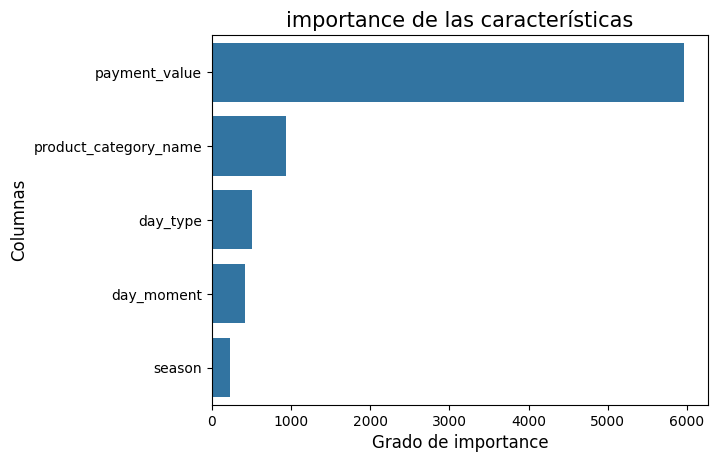

In [10]:
importance = pd.Series(model.feature_importances_, index=X.columns)
sns.barplot(x=importance.values, y=importance.index, order=importance.sort_values(ascending=False).index)
plt.title("importance de las características", fontsize=15)
plt.xlabel("Grado de importance", fontsize=12)
plt.ylabel("Columnas", fontsize=12)


In [11]:
cm = confusion_matrix(y_test, y_pred)

Text(70.72222222222221, 0.5, 'Clase Real (Cluster)')

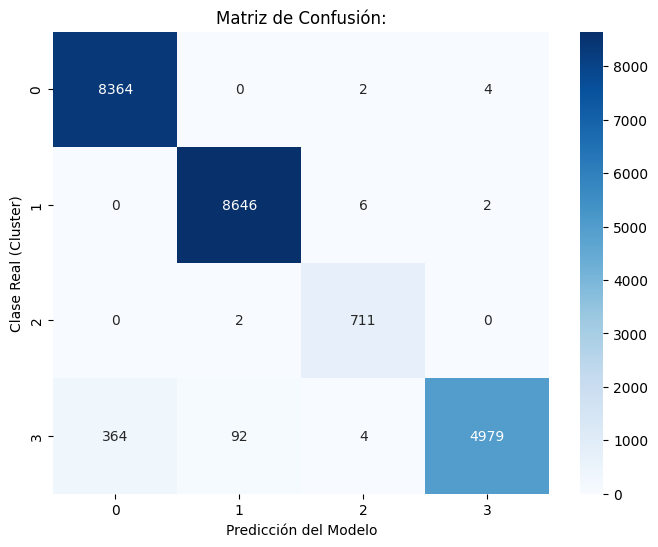

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión:")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Cluster)")

### Observaciones:
> - `8364` aciertos para el cluster 0. Hubo 6 casos donde el modelo clasifico erroneamente, que son casos del cluster 0.
> - `8646` aciertos para el cluster 1. Hubo 8 casos donde el modelo clasifico erroneamente, que son casos del cluster 1.
> - `711` aciertos para el cluster 2. Hubo 4 casos donde el modelo clasifico erroneamente, que son casos del cluster 2.
> - `4979` aciertos para el cluster 3. Hubo 460 casos donde el modelo clasifico erroneamente, que son casos del cluster 3.

### Concluciones: 
> - El modelo valida la segmentación de los clientes
> - El modelo aprendio a clasificar los clientes basandose en los patrones de comportamientos de compra.

## Guardar modelo

In [13]:
joblib.dump(model, "../models/lgbm_customer_classifier.pkl")

['../models/lgbm_customer_classifier.pkl']